## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/) Cod. 202321287
## Daniel Suaza Cod. 202311517
## Camilo Arebalo 202312721
# W10 - Complementaría

# Librerías

In [30]:
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex, atan2, pprint, init_printing, Derivative, sqrt, diff, Eq, tan, integrate, Function, dsolve
from sympy.physics.vector import dynamicsymbols, init_vprinting, ReferenceFrame
from numpy import deg2rad, linspace
import matplotlib.pyplot as plt

init_vprinting(use_latex='mathjax')

# ej1 
Calcular 𝜔_𝑛, 𝜁y 𝜔_𝑑 (si aplica) a partir de 𝑚,𝑐,𝑘.

In [31]:
# tenemos las siguientes expresiones

# Los casos son masa, k, c
casos = [
    (1, 4, 0.6),
    (1, 4, 4),
    (1, 4, 6)
]

resultados = []
for m, k, c in casos:
    w_n = (k / m) ** 0.5
    zeta = c / (2 * (k * m) ** 0.5)
    if 0 < zeta < 1:
        w_d = w_n * (1 - zeta ** 2) ** 0.5
    else:
        w_d = None
    resultados.append({'m': m, 'k': k, 'c': c, 'w_n': w_n, 'zeta': zeta, 'w_d': w_d})

for res in resultados:
    print(res)
    
print(resultados)

{'m': 1, 'k': 4, 'c': 0.6, 'w_n': 2.0, 'zeta': 0.15, 'w_d': 1.977371993328519}
{'m': 1, 'k': 4, 'c': 4, 'w_n': 2.0, 'zeta': 1.0, 'w_d': None}
{'m': 1, 'k': 4, 'c': 6, 'w_n': 2.0, 'zeta': 1.5, 'w_d': None}
[{'m': 1, 'k': 4, 'c': 0.6, 'w_n': 2.0, 'zeta': 0.15, 'w_d': 1.977371993328519}, {'m': 1, 'k': 4, 'c': 4, 'w_n': 2.0, 'zeta': 1.0, 'w_d': None}, {'m': 1, 'k': 4, 'c': 6, 'w_n': 2.0, 'zeta': 1.5, 'w_d': None}]


# ej2 
Ahora vamos a Derivar la solución analítica 𝑦(𝑡)para cada régimen con condiciones iniciales, esto es básicamente resolver la ODE 𝑚𝑦 ̈+𝑐𝑦 ̇+𝑘𝑦=0

In [32]:
t = symbols("t", real=True, positive=True)
m, c, k = symbols("m c k", real=True, positive=True)
y = Function('y')(t)

ecuacion = Eq(m * diff(y, t, t) + c * diff(y, t) + k * y, 0)

display(ecuacion)

sol_ecuacion = dsolve(ecuacion, y)

display(sol_ecuacion)

                         2           
  d                     d            
c⋅──(y(t)) + k⋅y(t) + m⋅───(y(t)) = 0
  dt                      2          
                        dt           

             ⎛        ____________⎞          ⎛       ____________⎞ 
             ⎜       ╱  2         ⎟          ⎜      ╱  2         ⎟ 
           t⋅⎝-c + ╲╱  c  - 4⋅k⋅m ⎠       -t⋅⎝c + ╲╱  c  - 4⋅k⋅m ⎠ 
           ────────────────────────       ─────────────────────────
                     2⋅m                             2⋅m           
y(t) = C₁⋅ℯ                         + C₂⋅ℯ                         

# ej3
Aquí lo que hacemo ses remplazar los valores y solucionar para cada uno de los casos, vamos a notar entonces que tenemos un caso crítico, subamortiguado y sobreamortiguado dependiendo el tiempo.

In [33]:
# Resolver la ecuación diferencial para cada caso con y(0)=0, y'(0)=1
y = Function('y')(t)
soluciones_casos = []

for caso in resultados:
    m_val, k_val, c_val = caso['m'], caso['k'], caso['c']
    eq_caso = ecuacion.subs({m: m_val, k: k_val, c: c_val})
    
    # Condiciones iniciales
    ics = {y.subs(t, 0): 0, diff(y, t).subs(t, 0): 1}
    
    sol_caso = dsolve(eq_caso, y, ics=ics)
    soluciones_casos.append({
        'm': m_val,
        'k': k_val,
        'c': c_val,
        'sol': sol_caso
    })

# Mostrar las soluciones con condiciones iniciales
for sol in soluciones_casos:
    print(f"m={sol['m']}, k={sol['k']}, c={sol['c']}")
    display(sol['sol'])


m=1, k=4, c=0.6


                          -0.3⋅t                        
y(t) = 0.505721737424173⋅ℯ      ⋅sin(1.97737199332852⋅t)

m=1, k=4, c=4


          -2⋅t
y(t) = t⋅ℯ    

m=1, k=4, c=6


           t⋅(-3 + √5)       -t⋅(√5 + 3)
       √5⋅ℯ              √5⋅ℯ           
y(t) = ─────────────── - ───────────────
             10                10       

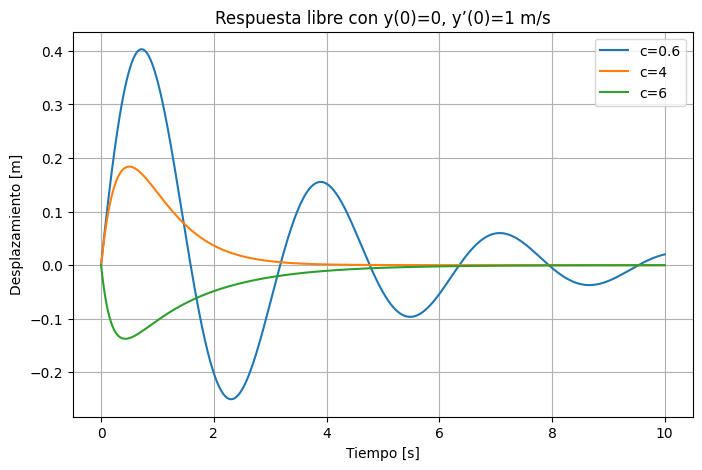

: 

In [ ]:
import numpy as np
t_vals = np.linspace(0, 10, 1000)
plt.figure(figsize=(8, 5))

for caso in resultados:
    m_val, k_val, c_val = caso['m'], caso['k'], caso['c']
    w_n = caso['w_n']
    zeta = caso['zeta']
    w_d = caso['w_d']

    if zeta < 1:  # Subamortiguado
        y_vals = (1 / (w_d)) * np.exp(-zeta * w_n * t_vals) * np.sin(w_d * t_vals)
    elif zeta == 1:  # Críticamente amortiguado
        y_vals = t_vals * np.exp(-w_n * t_vals)
    else:  # Sobreamortiguado
        r1 = -w_n * (zeta - np.sqrt(zeta**2 - 1))
        r2 = -w_n * (zeta + np.sqrt(zeta**2 - 1))
        y_vals = (np.exp(r1 * t_vals) - np.exp(r2 * t_vals)) / (r2 - r1)

    plt.plot(t_vals, y_vals, label=f'c={c_val}')

plt.title("Respuesta libre con y(0)=0, y’(0)=1 m/s")
plt.xlabel("Tiempo [s]") 
plt.ylabel("Desplazamiento [m]")
plt.legend()
plt.grid(True)
plt.show()


El sistema con ( c = 6 ) decae más rápido, ya que el coeficiente de amortiguamiento es mayor y por tanto la disipación de energía ocurre con mayor velocidad. El parámetro zeta (relación de amortiguamiento) controla la pendiente de la envolvente exponencial que limita las oscilaciones: a medida que zeta aumenta, la envolvente se hace más pronunciada y la amplitud tiende a cero en menos tiempo. En el régimen subamortiguado, el sistema aún oscila, pero el periodo aparente aumenta ligeramente respecto al caso no amortiguado, debido a que la frecuencia amortiguada es menor que la frecuencia natural. En resumen, un zeta grande acelera el decaimiento y reduce las oscilaciones, mientras que un zeta pequeño conserva el carácter oscilatorio.


Algo que si no entiendo es porque la curva con mayor amotiguamiento se va para abajo, pues en teóría todas deben tener las mismas condiciones iniciales.
